# Full-Scope Weighted 2PCF Convergence Analysis

> Goal: use all weighted 2PCF convergence CSV data in the repository, compare seeded vs non-seeded behavior across all available examples and mass-cut selections, evaluate multiple convergence metrics, and recommend an overall `n_subvol`.

> Constraint: this notebook is read-only on CSV inputs (no CSV modification).

In [2]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    fallback = Path("/cosma/apps/durham/dc-hick2/galform_analysis")
    return fallback if fallback.exists() else start


PROJECT_ROOT = find_repo_root(Path.cwd().resolve())
DATA_ROOT = PROJECT_ROOT / "data"

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Analysis controls
LARGE_SCALE_RMIN = 8.0
R2XI_RMIN, R2XI_RMAX = 3.0, 20.0
EPS = 1e-10
MIN_POINTS_PER_CURVE = 6

# Convergence pass thresholds (used in recommendation section)
THRESH_MEDIAN_ABS_FRAC = 0.10
THRESH_RMSE_FRAC = 0.15
THRESH_R2XI_REL = 0.05

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root exists: {DATA_ROOT.exists()}")
print("Thresholds:")
print(f"  median_abs_frac <= {THRESH_MEDIAN_ABS_FRAC:.3f}")
print(f"  rmse_frac       <= {THRESH_RMSE_FRAC:.3f}")
print(f"  r2xi_rel_err    <= {THRESH_R2XI_REL:.3f}")

Project root: /cosma/apps/durham/dc-hick2/galform_analysis
Data root exists: True
Thresholds:
  median_abs_frac <= 0.100
  rmse_frac       <= 0.150
  r2xi_rel_err    <= 0.050


In [9]:
FNAME_PATTERN = re.compile(
    r"(?P<prefix>halo|group)_sampling_convergence_(?P<mode>[^_]+)_(?P<sim>[^_]+)_iz(?P<iz>\d+)(?:_n(?P<n_subvol>\d+))?\.csv$"
)


def mode_to_weighted(mode_raw: str) -> str:
    m = str(mode_raw).lower().strip()
    if m in {"weighted", "halo"}:
        return "weighted"
    return m


def infer_model(path: Path) -> str:
    parts = [p.lower() for p in path.parts]
    if "lc16" in parts:
        return "lc16"
    if "gp14" in parts:
        return "gp14"
    return "unknown"


def parse_seed_from_path(path: Path) -> int:
    for part in path.parts:
        m = re.match(r"seed_(\d+)$", part)
        if m:
            return int(m.group(1))
    return -1


def parse_n_subvol_from_path(path: Path):
    for part in path.parts:
        m = re.match(r"nsubvol_(\d+)$", part)
        if m:
            return int(m.group(1))
    return None


def parse_mhalo_tag(path: Path) -> str:
    for part in path.parts:
        m = re.search(r"mhalo_?([0-9eE.+-]+)", part)
        if m:
            return m.group(1)
    return "unknown"


def parse_centrals_only(path: Path, df: pd.DataFrame) -> int:
    if "centrals_only" in df.columns:
        val = pd.to_numeric(df["centrals_only"], errors="coerce").dropna()
        if not val.empty:
            return int(val.iloc[0])

    for part in path.parts:
        p = part.lower()
        if p.endswith("_cen") or p == "cen":
            return 1
        if p.endswith("_all") or p == "all":
            return 0
    return -1


def infer_xi_shift_for_file(curve: pd.DataFrame, rmin: float = LARGE_SCALE_RMIN) -> float:
    tail = curve.loc[curve["r"] >= rmin, "xi"].dropna()
    if tail.empty:
        return 0.0
    med = float(tail.median())
    return 1.0 if (0.7 <= med <= 1.3) else 0.0


candidate_files = sorted(DATA_ROOT.rglob("*sampling_convergence_*_iz*.csv"))
print(f"Candidate convergence CSV files: {len(candidate_files)}")

curve_frames = []
catalog_rows = []
skip_rows = []

for csv_path in candidate_files:
    rel = csv_path.relative_to(DATA_ROOT)
    m = FNAME_PATTERN.match(csv_path.name)
    if not m:
        skip_rows.append({"file": str(rel), "reason": "name_pattern_mismatch"})
        continue

    mode_raw = m.group("mode")
    mode_norm = mode_to_weighted(mode_raw)
    if mode_norm != "weighted":
        skip_rows.append({"file": str(rel), "reason": f"mode_not_weighted:{mode_raw}"})
        continue

    try:
        df = pd.read_csv(csv_path)
    except Exception as exc:
        skip_rows.append({"file": str(rel), "reason": f"read_error:{exc}"})
        continue

    if df.empty:
        skip_rows.append({"file": str(rel), "reason": "empty_csv"})
        continue

    if not {"r", "xi"}.issubset(df.columns):
        skip_rows.append({"file": str(rel), "reason": "missing_r_or_xi"})
        continue

    n_subvol = None
    if "n_subvol" in df.columns:
        n_series = pd.to_numeric(df["n_subvol"], errors="coerce").dropna()
        if not n_series.empty:
            n_subvol = int(n_series.iloc[0])
    if n_subvol is None and m.group("n_subvol") is not None:
        n_subvol = int(m.group("n_subvol"))
    if n_subvol is None:
        n_subvol = parse_n_subvol_from_path(csv_path)
    if n_subvol is None:
        skip_rows.append({"file": str(rel), "reason": "missing_n_subvol"})
        continue

    curve = df[["r", "xi"]].copy()
    curve["r"] = pd.to_numeric(curve["r"], errors="coerce")
    curve["xi"] = pd.to_numeric(curve["xi"], errors="coerce")
    curve = (
        curve.dropna(subset=["r", "xi"])
        .groupby("r", as_index=False).agg(xi=("xi", "mean")).sort_values("r")
    )
    if len(curve) < MIN_POINTS_PER_CURVE:
        skip_rows.append({"file": str(rel), "reason": "too_few_curve_points"})
        continue

    xi_shift = infer_xi_shift_for_file(curve)
    curve["xi_clean"] = curve["xi"] - xi_shift

    model = infer_model(csv_path)
    sim = m.group("sim")
    iz = int(m.group("iz"))
    mhalo_tag = parse_mhalo_tag(csv_path)
    centrals_only = parse_centrals_only(csv_path, df)

    selection_seed = parse_seed_from_path(csv_path)
    if "selection_seed" in df.columns:
        seed_vals = pd.to_numeric(df["selection_seed"], errors="coerce").dropna()
        if not seed_vals.empty:
            selection_seed = int(seed_vals.iloc[0])

    is_seeded = "seeded" in rel.parts[0].lower()
    seeded_status = "seeded" if is_seeded else "non_seeded"

    example_root = rel.parts[0]
    example_family = example_root.replace("_seeded", "")
    example_context = "/".join(rel.parts[:3]) if len(rel.parts) >= 3 else "/".join(rel.parts[:-1])

    file_id = str(rel)
    curve["file_id"] = file_id
    curve["example_root"] = example_root
    curve["example_family"] = example_family
    curve["example_context"] = example_context
    curve["model"] = model
    curve["sim"] = sim
    curve["iz"] = iz
    curve["mode_raw"] = mode_raw
    curve["mode_norm"] = mode_norm
    curve["n_subvol"] = int(n_subvol)
    curve["mhalo_tag"] = mhalo_tag
    curve["centrals_only"] = int(centrals_only)
    curve["selection_seed"] = int(selection_seed)
    curve["seeded_status"] = seeded_status
    curve["xi_shift"] = xi_shift

    curve_frames.append(curve)
    catalog_rows.append(
        {
            "file_id": file_id,
            "example_root": example_root,
            "example_family": example_family,
            "example_context": example_context,
            "model": model,
            "sim": sim,
            "iz": iz,
            "mode_raw": mode_raw,
            "mode_norm": mode_norm,
            "n_subvol": int(n_subvol),
            "mhalo_tag": mhalo_tag,
            "centrals_only": int(centrals_only),
            "selection_seed": int(selection_seed),
            "seeded_status": seeded_status,
            "xi_shift": xi_shift,
            "n_points": len(curve),
        }
    )

all_curves = pd.concat(curve_frames, ignore_index=True) if curve_frames else pd.DataFrame()
file_catalog = pd.DataFrame(catalog_rows)
skip_df = pd.DataFrame(skip_rows)

print(f"Loaded weighted curves from files: {len(file_catalog)}")
print(f"Skipped files: {len(skip_df)}")
if not file_catalog.empty:
    print("Unique examples:", file_catalog["example_root"].nunique())
    print("Unique combos (family/model/sim/iz/mhalo/centrals/seeded):")
    combo_cols_preview = ["example_family", "model", "sim", "iz", "mhalo_tag", "centrals_only", "seeded_status"]
    print(file_catalog[combo_cols_preview].drop_duplicates().shape[0])

    display(
        file_catalog.groupby(["example_root", "seeded_status"], as_index=False)
        .agg(files=("file_id", "nunique"), n_values=("n_subvol", "nunique"))
        .sort_values(["example_root", "seeded_status"])
)

    display(
        file_catalog.groupby(["model", "sim", "seeded_status"], as_index=False)
        .agg(files=("file_id", "nunique"), n_values=("n_subvol", "nunique"))
        .sort_values(["model", "sim", "seeded_status"])
)

    display(
        file_catalog["n_subvol"].value_counts().sort_index().rename_axis("n_subvol").to_frame("files")
)

if not skip_df.empty:
    display(skip_df["reason"].value_counts().rename_axis("reason").to_frame("count").head(20))

Candidate convergence CSV files: 3097
Loaded weighted curves from files: 2671
Skipped files: 426
Unique examples: 9
Unique combos (family/model/sim/iz/mhalo/centrals/seeded):
121


,example_root,seeded_status,files,n_values
0,convergence,non_seeded,233,20
1,halo_sampling_2,non_seeded,190,16
2,halo_sampling_3,non_seeded,190,16
3,halo_sampling_4_subvol_weighted,non_seeded,175,15
4,halo_sampling_4_subvol_weighted_random,non_seeded,248,15
5,halo_sampling_4_subvol_weighted_random_seeded,seeded,249,15
6,halo_sampling_6_subvol_weighted_mstar_scan,non_seeded,896,15
7,halo_sampling_data,non_seeded,272,86
8,halo_sampling_mstar_scan,non_seeded,218,16


,model,sim,seeded_status,files,n_values
0,gp14,L800,non_seeded,18,5
1,gp14,Mill1,non_seeded,15,12
2,lc16,L800,non_seeded,2371,86
3,lc16,L800,seeded,249,15
4,unknown,L800,non_seeded,18,5


,files
n_subvol,
1,68
2,163
3,2
4,165
5,2
...,...
600,161
700,6
800,159


,count
reason,
mode_not_weighted:normal,268
too_few_curve_points,142
mode_not_weighted:corrfunc,16


In [11]:
combo_cols = [
    "example_family",
    "model",
    "sim",
    "iz",
    "mode_norm",
    "mhalo_tag",
    "centrals_only",
]
status_col = "seeded_status"

if all_curves.empty:
    curve_mean = pd.DataFrame()
    conv_metrics = pd.DataFrame()
    seed_vs_nonseed = pd.DataFrame()
    print("No weighted convergence curves were loaded.")
else:
    curve_mean = (
        all_curves.groupby(combo_cols + [status_col, "n_subvol", "r"], as_index=False)
        .agg(
            xi_mean=("xi_clean", "mean"),
            xi_std=("xi_clean", "std"),
            n_file_curves=("file_id", "nunique"),
            n_seed_values=("selection_seed", lambda s: int((s >= 0).sum())),
        )
        .sort_values(combo_cols + [status_col, "n_subvol", "r"])
)

    def compute_convergence_metrics(curve_df: pd.DataFrame) -> pd.DataFrame:
        rows = []
        group_cols = combo_cols + [status_col]

        for key_vals, g in curve_df.groupby(group_cols):
            key_tuple = key_vals if isinstance(key_vals, tuple) else (key_vals,)
            key = dict(zip(group_cols, key_tuple))

            n_vals = sorted(g["n_subvol"].dropna().astype(int).unique().tolist())
            if len(n_vals) < 2:
                continue

            n_ref = int(max(n_vals))
            ref = g[g["n_subvol"].astype(int) == n_ref][["r", "xi_mean"]].rename(
                columns={"xi_mean": "xi_ref"}
)

            for n in n_vals:
                n = int(n)
                cur = g[g["n_subvol"].astype(int) == n][["r", "xi_mean"]].rename(
                    columns={"xi_mean": "xi_n"}
)

                merged = cur.merge(ref, on="r", how="inner").dropna()
                if len(merged) < MIN_POINTS_PER_CURVE:
                    continue

                frac = np.abs((merged["xi_n"] - merged["xi_ref"]) / (np.abs(merged["xi_ref"]) + EPS))
                rmse_frac = float(
                    np.sqrt(np.mean(((merged["xi_n"] - merged["xi_ref"]) / (np.abs(merged["xi_ref"]) + EPS)) ** 2))
)
                med_abs_frac = float(np.nanmedian(frac))
                p90_abs_frac = float(np.nanpercentile(frac, 90))
                med_abs_delta = float(np.nanmedian(np.abs(merged["xi_n"] - merged["xi_ref"])))

                rmask = (merged["r"] >= R2XI_RMIN) & (merged["r"] <= R2XI_RMAX)
                if rmask.any():
                    r2xi_n = float(np.nanmean((merged.loc[rmask, "r"] ** 2) * merged.loc[rmask, "xi_n"]))
                    r2xi_ref = float(np.nanmean((merged.loc[rmask, "r"] ** 2) * merged.loc[rmask, "xi_ref"]))
                    r2xi_rel_err = float(np.abs(r2xi_n - r2xi_ref) / (np.abs(r2xi_ref) + EPS))
                else:
                    r2xi_n = np.nan
                    r2xi_ref = np.nan
                    r2xi_rel_err = np.nan

                rows.append(
                    {
                        **key,
                        "n_subvol": n,
                        "n_ref": n_ref,
                        "n_points": int(len(merged)),
                        "median_abs_frac": med_abs_frac,
                        "p90_abs_frac": p90_abs_frac,
                        "rmse_frac": rmse_frac,
                        "median_abs_delta": med_abs_delta,
                        "r2xi_n": r2xi_n,
                        "r2xi_ref": r2xi_ref,
                        "r2xi_rel_err": r2xi_rel_err,
                    }
                )

        out = pd.DataFrame(rows)
        if not out.empty:
            out["combo_id"] = out[combo_cols + [status_col]].astype(str).agg("|".join, axis=1)
        return out

    def compute_seeded_vs_nonseed(curve_df: pd.DataFrame) -> pd.DataFrame:
        rows = []

        for key_vals, g in curve_df.groupby(combo_cols):
            key_tuple = key_vals if isinstance(key_vals, tuple) else (key_vals,)
            key = dict(zip(combo_cols, key_tuple))

            g_base = g[g[status_col] == "non_seeded"]
            g_seed = g[g[status_col] == "seeded"]
            if g_base.empty or g_seed.empty:
                continue

            base_n = set(g_base["n_subvol"].dropna().astype(int).tolist())
            seed_n = set(g_seed["n_subvol"].dropna().astype(int).tolist())
            common_n = sorted(base_n.intersection(seed_n))

            for n in common_n:
                n = int(n)
                b = g_base[g_base["n_subvol"].astype(int) == n][["r", "xi_mean"]].rename(
                    columns={"xi_mean": "xi_base"}
)
                s = g_seed[g_seed["n_subvol"].astype(int) == n][["r", "xi_mean"]].rename(
                    columns={"xi_mean": "xi_seed"}
)

                merged = b.merge(s, on="r", how="inner").dropna()
                if len(merged) < MIN_POINTS_PER_CURVE:
                    continue

                frac_pct = np.abs((merged["xi_seed"] - merged["xi_base"]) / (np.abs(merged["xi_base"]) + EPS)) * 100.0
                rmse_pct = float(
                    np.sqrt(np.mean(((merged["xi_seed"] - merged["xi_base"]) / (np.abs(merged["xi_base"]) + EPS)) ** 2)) * 100.0
)
                med_abs_pct = float(np.nanmedian(frac_pct))
                p90_abs_pct = float(np.nanpercentile(frac_pct, 90))

                rmask = (merged["r"] >= R2XI_RMIN) & (merged["r"] <= R2XI_RMAX)
                if rmask.any():
                    r2_base = float(np.nanmean((merged.loc[rmask, "r"] ** 2) * merged.loc[rmask, "xi_base"]))
                    r2_seed = float(np.nanmean((merged.loc[rmask, "r"] ** 2) * merged.loc[rmask, "xi_seed"]))
                    r2_pct = float(np.abs(r2_seed - r2_base) / (np.abs(r2_base) + EPS) * 100.0)
                else:
                    r2_pct = np.nan

                rows.append(
                    {
                        **key,
                        "n_subvol": n,
                        "n_points": int(len(merged)),
                        "median_abs_pct_diff": med_abs_pct,
                        "p90_abs_pct_diff": p90_abs_pct,
                        "rmse_pct_diff": rmse_pct,
                        "r2xi_pct_diff": r2_pct,
                    }
                )

        out = pd.DataFrame(rows)
        if not out.empty:
            out["combo_id"] = out[combo_cols].astype(str).agg("|".join, axis=1)
        return out

    conv_metrics = compute_convergence_metrics(curve_mean)
    seed_vs_nonseed = compute_seeded_vs_nonseed(curve_mean)

    if conv_metrics.empty:
        print("No convergence metrics could be computed (need at least 2 n_subvol per combo).")
    else:
        conv_metrics["passes_thresholds"] = (
            (conv_metrics["median_abs_frac"] <= THRESH_MEDIAN_ABS_FRAC)
            & (conv_metrics["rmse_frac"] <= THRESH_RMSE_FRAC)
            & (conv_metrics["r2xi_rel_err"] <= THRESH_R2XI_REL)
)
        print(f"Convergence rows: {len(conv_metrics)}")
        print(f"Unique combo+status groups: {conv_metrics['combo_id'].nunique()}")

    if seed_vs_nonseed.empty:
        print("No seeded-vs-non-seeded overlap was found for direct comparison.")
    else:
        print(f"Seeded-vs-non-seeded rows: {len(seed_vs_nonseed)}")
        print(f"Unique combo groups: {seed_vs_nonseed['combo_id'].nunique()}")

Convergence rows: 1757
Unique combo+status groups: 120
Seeded-vs-non-seeded rows: 248
Unique combo groups: 18


In [12]:
if conv_metrics.empty:
    print("No convergence metrics to summarize.")
else:
    summary_by_example = (
        conv_metrics.groupby(["example_family", "seeded_status"], as_index=False)
        .agg(
            rows=("n_subvol", "size"),
            combos=("combo_id", "nunique"),
            median_median_abs_frac=("median_abs_frac", "median"),
            p90_median_abs_frac=("median_abs_frac", lambda s: float(np.nanpercentile(s, 90))),
            pass_rate=("passes_thresholds", "mean"),
        )
        .sort_values(["example_family", "seeded_status"])
)

    summary_by_mass = (
        conv_metrics.groupby(["mhalo_tag", "seeded_status"], as_index=False)
        .agg(
            rows=("n_subvol", "size"),
            combos=("combo_id", "nunique"),
            median_median_abs_frac=("median_abs_frac", "median"),
            p90_median_abs_frac=("median_abs_frac", lambda s: float(np.nanpercentile(s, 90))),
            pass_rate=("passes_thresholds", "mean"),
        )
        .sort_values(["mhalo_tag", "seeded_status"])
)

    agg_n_status = (
        conv_metrics.groupby(["seeded_status", "n_subvol"], as_index=False)
        .agg(
            rows=("n_subvol", "size"),
            combos=("combo_id", "nunique"),
            med_median_abs_frac=("median_abs_frac", "median"),
            p90_median_abs_frac=("median_abs_frac", lambda s: float(np.nanpercentile(s, 90))),
            med_rmse_frac=("rmse_frac", "median"),
            p90_rmse_frac=("rmse_frac", lambda s: float(np.nanpercentile(s, 90))),
            med_r2xi_rel=("r2xi_rel_err", "median"),
            p90_r2xi_rel=("r2xi_rel_err", lambda s: float(np.nanpercentile(s, 90))),
            pass_rate=("passes_thresholds", "mean"),
        )
        .sort_values(["seeded_status", "n_subvol"])
)

    print("Summary by example family and seeded status:")
    display(summary_by_example)

    print("Summary by mhalo tag and seeded status:")
    display(summary_by_mass)

    print("Aggregated convergence by n_subvol and seeded status:")
    display(agg_n_status)

if seed_vs_nonseed.empty:
    print("No seeded vs non-seeded overlap table to display.")
else:
    overlap_summary = (
        seed_vs_nonseed.groupby("n_subvol", as_index=False)
        .agg(
            rows=("n_subvol", "size"),
            combos=("combo_id", "nunique"),
            med_abs_pct_diff=("median_abs_pct_diff", "median"),
            p90_abs_pct_diff=("median_abs_pct_diff", lambda s: float(np.nanpercentile(s, 90))),
            med_rmse_pct_diff=("rmse_pct_diff", "median"),
            med_r2xi_pct_diff=("r2xi_pct_diff", "median"),
        )
        .sort_values("n_subvol")
)
    print("Seeded vs non-seeded overlap summary:")
    display(overlap_summary)

Summary by example family and seeded status:


,example_family,seeded_status,rows,combos,median_median_abs_frac,p90_median_abs_frac,pass_rate
0,convergence,non_seeded,226,23,0.466075,37.033784,0.261062
1,halo_sampling_2,non_seeded,190,12,0.516897,6.057165,0.284211
2,halo_sampling_3,non_seeded,190,12,0.736657,6.057165,0.094737
3,halo_sampling_4_subvol_weighted,non_seeded,175,12,0.032347,0.367669,0.617143
4,halo_sampling_4_subvol_weighted_random,non_seeded,248,18,0.044950,0.472938,0.403226
5,halo_sampling_4_subvol_weighted_random,seeded,249,18,0.061469,0.716313,0.345382
6,halo_sampling_6_subvol_weighted_mstar_scan,non_seeded,180,12,0.082233,0.584031,0.366667
7,halo_sampling_data,non_seeded,253,10,0.033637,0.202612,0.644269
8,halo_sampling_mstar_scan,non_seeded,46,3,0.808420,62.795581,0.173913


Summary by mhalo tag and seeded status:


,mhalo_tag,seeded_status,rows,combos,median_median_abs_frac,p90_median_abs_frac,pass_rate
0,1e10,non_seeded,63,6,2.878920,58.597834,0.174603
1,1e11,non_seeded,651,36,0.059646,1.661018,0.440860
2,1e11,seeded,90,6,0.070307,0.262703,0.388889
3,1e13,non_seeded,73,6,0.147241,0.900138,0.136986
4,1e13,seeded,73,6,0.212339,0.872725,0.136986
5,1e9,non_seeded,629,43,0.109529,4.134053,0.367250
6,1e9,seeded,86,6,0.019537,0.149331,0.476744
7,unknown,non_seeded,92,11,0.083139,15.780721,0.402174


Aggregated convergence by n_subvol and seeded status:


,seeded_status,n_subvol,rows,combos,med_median_abs_frac,p90_median_abs_frac,med_rmse_frac,p90_rmse_frac,med_r2xi_rel,p90_r2xi_rel,pass_rate
0,non_seeded,1,53,53,4.465597,136.535758,10.748900,290.989644,7.064252,127.076928,0.000000
1,non_seeded,2,89,89,0.851402,32.502277,4.722618,41.475889,2.608074,18.591698,0.011236
2,non_seeded,3,2,2,0.181731,0.250679,0.608402,0.812219,0.277589,0.494212,0.000000
3,non_seeded,4,90,90,0.449982,19.797221,0.823731,22.224171,0.196603,13.888401,0.044444
4,non_seeded,5,2,2,0.270319,0.403438,0.600948,0.744236,0.089745,0.150611,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
98,seeded,200,18,18,0.023875,0.077193,0.046788,0.219200,0.020310,0.049584,0.722222
99,seeded,400,18,18,0.008050,0.051865,0.020004,0.265619,0.008645,0.016284,0.777778
100,seeded,600,18,18,0.010906,0.038795,0.016104,0.304790,0.008684,0.015844,0.722222
101,seeded,800,16,16,0.011715,0.031168,0.013396,0.306756,0.010291,0.017890,0.625000


Seeded vs non-seeded overlap summary:


,n_subvol,rows,combos,med_abs_pct_diff,p90_abs_pct_diff,med_rmse_pct_diff,med_r2xi_pct_diff
0,2,12,12,47.067074,104.799621,253.288505,17.393756
1,4,13,13,15.509560,59.119356,117.530375,54.334422
2,8,16,16,22.476950,92.705412,39.991416,42.401580
3,10,16,16,17.644911,98.311547,34.654108,50.474104
4,15,16,16,13.748151,54.148117,28.504978,37.820277
5,20,18,18,14.712035,115.950563,25.952686,20.227550
6,25,18,18,15.572743,162.397315,17.398906,10.654189
7,30,18,18,12.013795,384.667172,14.196023,3.814389
8,50,18,18,8.787048,52.624249,10.614331,3.391824
9,100,18,18,5.882006,14.454654,7.055817,3.354918


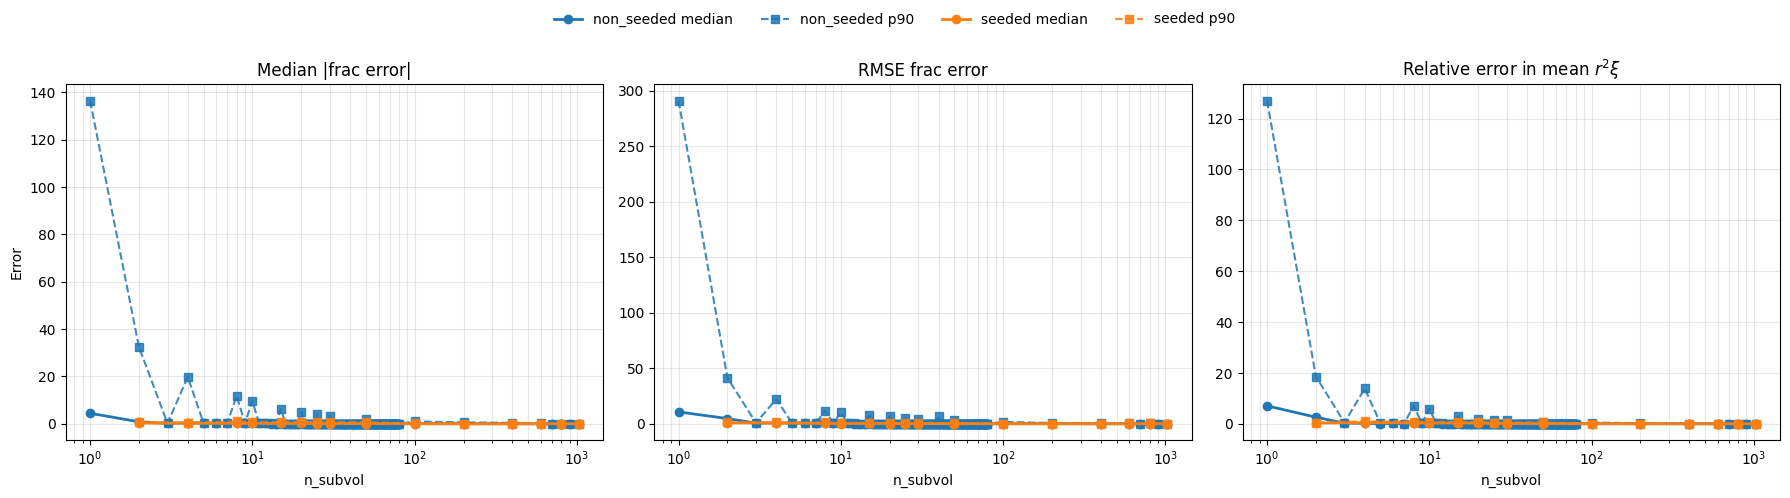

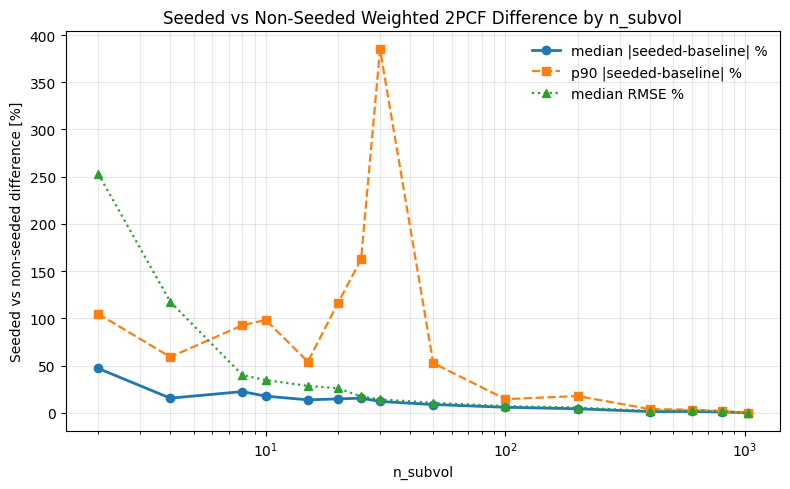

In [13]:
if conv_metrics.empty:
    print("No convergence metrics to plot.")
else:
    plot_df = (
        conv_metrics.groupby(["seeded_status", "n_subvol"], as_index=False)
        .agg(
            med_median_abs_frac=("median_abs_frac", "median"),
            p90_median_abs_frac=("median_abs_frac", lambda s: float(np.nanpercentile(s, 90))),
            med_rmse_frac=("rmse_frac", "median"),
            p90_rmse_frac=("rmse_frac", lambda s: float(np.nanpercentile(s, 90))),
            med_r2xi_rel=("r2xi_rel_err", "median"),
            p90_r2xi_rel=("r2xi_rel_err", lambda s: float(np.nanpercentile(s, 90))),
        )
        .sort_values(["seeded_status", "n_subvol"])
)

    metric_specs = [
        ("med_median_abs_frac", "p90_median_abs_frac", "Median |frac error|"),
        ("med_rmse_frac", "p90_rmse_frac", "RMSE frac error"),
        ("med_r2xi_rel", "p90_r2xi_rel", r"Relative error in mean $r^2\xi$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    statuses = ["non_seeded", "seeded"]
    colors = {"non_seeded": "tab:blue", "seeded": "tab:orange"}

    for ax, (med_col, p90_col, title) in zip(axes, metric_specs):
        for status in statuses:
            sdf = plot_df[plot_df["seeded_status"] == status].sort_values("n_subvol")
            if sdf.empty:
                continue
            ax.plot(
                sdf["n_subvol"],
                sdf[med_col],
                marker="o",
                lw=2,
                color=colors[status],
                label=f"{status} median",
            )
            ax.plot(
                sdf["n_subvol"],
                sdf[p90_col],
                marker="s",
                lw=1.5,
                ls="--",
                color=colors[status],
                alpha=0.85,
                label=f"{status} p90",
            )
        ax.set_xscale("log")
        ax.grid(alpha=0.3, which="both")
        ax.set_xlabel("n_subvol")
        ax.set_title(title)

    axes[0].set_ylabel("Error")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

if seed_vs_nonseed.empty:
    print("No seeded-vs-non-seeded overlap to plot.")
else:
    overlap_plot = (
        seed_vs_nonseed.groupby("n_subvol", as_index=False)
        .agg(
            med_abs_pct=("median_abs_pct_diff", "median"),
            p90_abs_pct=("median_abs_pct_diff", lambda s: float(np.nanpercentile(s, 90))),
            med_rmse_pct=("rmse_pct_diff", "median"),
        )
        .sort_values("n_subvol")
)

    plt.figure(figsize=(8, 5))
    plt.plot(overlap_plot["n_subvol"], overlap_plot["med_abs_pct"], marker="o", lw=2, label="median |seeded-baseline| %")
    plt.plot(overlap_plot["n_subvol"], overlap_plot["p90_abs_pct"], marker="s", lw=1.6, ls="--", label="p90 |seeded-baseline| %")
    plt.plot(overlap_plot["n_subvol"], overlap_plot["med_rmse_pct"], marker="^", lw=1.6, ls=":", label="median RMSE %")
    plt.xscale("log")
    plt.grid(alpha=0.3, which="both")
    plt.xlabel("n_subvol")
    plt.ylabel("Seeded vs non-seeded difference [%]")
    plt.title("Seeded vs Non-Seeded Weighted 2PCF Difference by n_subvol")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

In [15]:
if conv_metrics.empty:
    print("No convergence metrics available for recommendation.")
else:
    eval_df = conv_metrics.copy()
    eval_df = eval_df[
        np.isfinite(eval_df["median_abs_frac"])
 & np.isfinite(eval_df["rmse_frac"])
 & np.isfinite(eval_df["r2xi_rel_err"])
    ].copy()

    eval_df["pass_all"] = (
        (eval_df["median_abs_frac"] <= THRESH_MEDIAN_ABS_FRAC)
        & (eval_df["rmse_frac"] <= THRESH_RMSE_FRAC)
        & (eval_df["r2xi_rel_err"] <= THRESH_R2XI_REL)
    )

    by_n_total = (
        eval_df.groupby("n_subvol", as_index=False)
        .agg(
            rows=("n_subvol", "size"),
            combos=("combo_id", "nunique"),
            pass_rate=("pass_all", "mean"),
            med_median_abs_frac=("median_abs_frac", "median"),
            med_rmse_frac=("rmse_frac", "median"),
            med_r2xi_rel=("r2xi_rel_err", "median"),
        )
        .sort_values("n_subvol")
    )

    by_n_status = (
        eval_df.groupby(["n_subvol", "seeded_status"], as_index=False)
        .agg(
            rows=("n_subvol", "size"),
            combos=("combo_id", "nunique"),
            pass_rate=("pass_all", "mean"),
        )
        .sort_values(["n_subvol", "seeded_status"])
    )

    status_pivot = by_n_status.pivot(index="n_subvol", columns="seeded_status", values="pass_rate")
    count_pivot = by_n_status.pivot(index="n_subvol", columns="seeded_status", values="combos")

    recommendation_table = (
        by_n_total.set_index("n_subvol")
        .join(
            status_pivot.rename(
                columns={
                    "seeded": "pass_rate_seeded",
                    "non_seeded": "pass_rate_non_seeded",
                }
            )
        )
        .join(
            count_pivot.rename(
                columns={
                    "seeded": "combos_seeded",
                    "non_seeded": "combos_non_seeded",
                }
            )
        )
        .reset_index()
        .sort_values("n_subvol")
    )

    MIN_COMBOS_REQUIRED = 20
    PASS_RATE_TARGET_ALL = 0.80
    PASS_RATE_TARGET_STATUS = 0.75

    eligible = recommendation_table[recommendation_table["combos"] >= MIN_COMBOS_REQUIRED].copy()

    if eligible.empty:
        recommended_n = int(
            recommendation_table.sort_values(["pass_rate", "n_subvol"], ascending=[False, True]).iloc[0]["n_subvol"]
        )
        recommendation_reason = (
            "No n_subvol met minimum combo coverage filter; chose best pass-rate among available n_subvol."
        )
    else:
        meets = eligible[
            (eligible["pass_rate"] >= PASS_RATE_TARGET_ALL)
            & (eligible["pass_rate_seeded"].fillna(0.0) >= PASS_RATE_TARGET_STATUS)
            & (eligible["pass_rate_non_seeded"].fillna(0.0) >= PASS_RATE_TARGET_STATUS)
        ]

        if not meets.empty:
            recommended_n = int(meets.sort_values("n_subvol").iloc[0]["n_subvol"])
            recommendation_reason = "Smallest n_subvol meeting overall and per-status pass-rate targets."
        else:
            best = eligible.sort_values(["pass_rate", "n_subvol"], ascending=[False, True]).iloc[0]
            recommended_n = int(best["n_subvol"])
            recommendation_reason = (
                "No n_subvol met strict targets; chose best pass-rate with sufficient combo coverage."
            )

    print("Overall recommendation")
    print("----------------------")
    print(f"Recommended n_subvol: {recommended_n}")
    print(f"Reason: {recommendation_reason}")
    print(
        f"Targets: pass_all>={PASS_RATE_TARGET_ALL:.2f}, seeded>={PASS_RATE_TARGET_STATUS:.2f}, "
        f"non_seeded>={PASS_RATE_TARGET_STATUS:.2f}, combos>={MIN_COMBOS_REQUIRED}"
    )

    display(recommendation_table)

    mass_rows = []
    for mhalo_tag, g in eval_df.groupby("mhalo_tag"):
        mass_by_n = (
            g.groupby("n_subvol", as_index=False)
            .agg(combos=("combo_id", "nunique"), pass_rate=("pass_all", "mean"))
            .sort_values("n_subvol")
        )

        mass_eligible = mass_by_n[mass_by_n["combos"] >= 10]
        if not mass_eligible.empty:
            mass_meets = mass_eligible[mass_eligible["pass_rate"] >= 0.80]
            if not mass_meets.empty:
                mass_n = int(mass_meets.iloc[0]["n_subvol"])
                why = "first n with pass_rate>=0.80"
            else:
                best_row = mass_eligible.sort_values(["pass_rate", "n_subvol"], ascending=[False, True]).iloc[0]
                mass_n = int(best_row["n_subvol"])
                why = "best available pass_rate"
        else:
            best_row = mass_by_n.sort_values(["pass_rate", "n_subvol"], ascending=[False, True]).iloc[0]
            mass_n = int(best_row["n_subvol"])
            why = "low coverage, best available pass_rate"

        mass_rows.append(
            {
                "mhalo_tag": mhalo_tag,
                "recommended_n_subvol": mass_n,
                "reason": why,
            }
        )

    mass_recommendations = pd.DataFrame(mass_rows).sort_values("mhalo_tag")
    print("Mass-cut-specific recommendations:")
    display(mass_recommendations)

Overall recommendation
----------------------
Recommended n_subvol: 1024
Reason: Smallest n_subvol meeting overall and per-status pass-rate targets.
Targets: pass_all>=0.80, seeded>=0.75, non_seeded>=0.75, combos>=20


,n_subvol,rows,combos,pass_rate,med_median_abs_frac,med_rmse_frac,med_r2xi_rel,pass_rate_non_seeded,pass_rate_seeded,combos_non_seeded,combos_seeded
0,1,53,53,0.000000,4.465597,10.748900,7.064252,0.000000,NaN,53.0,NaN
1,2,101,101,0.009901,0.720327,2.379126,1.747905,0.011236,0.000000,89.0,12.0
2,3,2,2,0.000000,0.181731,0.608402,0.277589,0.000000,NaN,2.0,NaN
3,4,103,103,0.048544,0.390352,0.806193,0.222878,0.044444,0.076923,90.0,13.0
4,5,2,2,0.000000,0.270319,0.600948,0.089745,0.000000,NaN,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
83,600,104,104,0.663462,0.011192,0.026354,0.008475,0.651163,0.722222,86.0,18.0
84,700,6,6,0.666667,0.023818,0.098177,0.015846,0.666667,NaN,6.0,NaN
85,800,98,98,0.795918,0.005840,0.012965,0.004068,0.829268,0.625000,82.0,16.0
86,900,6,6,1.000000,0.011087,0.032024,0.005424,1.000000,NaN,6.0,NaN


Mass-cut-specific recommendations:


,mhalo_tag,recommended_n_subvol,reason
0,1e10,600,"low coverage, best available pass_rate"
1,1e11,800,first n with pass_rate>=0.80
2,1e13,1024,first n with pass_rate>=0.80
3,1e9,800,first n with pass_rate>=0.80
4,unknown,64,"low coverage, best available pass_rate"
